In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import xgboost as xgb

from sklearn.ensemble import StackingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import shap
from captum.attr import IntegratedGradients
# ==========================
# NEW IMPORTS ADDED
# ==========================
!pip install imbalanced-learn lightgbm pytorch-tabnet optuna
from collections import Counter

from imblearn.over_sampling import SMOTE, ADASYN
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import optuna
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [2]:
# ==========================
# 1. LOAD AND COMBINE EXCEL FILES
# ==========================

excel_files = [
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\angul_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\angul_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\angul_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\balasore_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\barbil_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\barbil_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\barbil_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\baripada_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\baripada_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\baripada_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\cuttack_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\cuttack_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\cuttack_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\cuttack_4.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\keonjhar_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\keonjhar_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\keonjhar_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\keonjhar_4.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\lingraj_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\lingraj_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\lingraj_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\lingraj_4.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\nayaghad_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\nayaghad_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\nayaghad_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\nayaghad_4.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\patia_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\Raigangpur_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\talcher_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\talcher_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\talcher_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\talcher_4.xlsx",
]

df_list = []
skipped = []

for path in excel_files:
    if not os.path.exists(path):
        skipped.append(path)
        continue
    try:
        df_list.append(pd.read_excel(path))
    except Exception as e:
        skipped.append(f"{path}  |  error: {e}")

if len(df_list) == 0:
    raise FileNotFoundError("No Excel files were successfully loaded. Check paths / files.")

data = pd.concat(df_list, ignore_index=True)

print(f" Loaded files: {len(df_list)}")
if skipped:
    print(f" Skipped files: {len(skipped)} (missing or error)")
    for s in skipped[:5]:
        print("   -", s)

# ==========================
# Basic cleaning
# ==========================
data.columns = [c.strip() for c in data.columns]   # remove accidental spaces in column names
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# ==========================
# Missing value handling 
# ==========================
# Forward fill first, then remaining NaNs filled by median (safer than only ffill)
data = data.sort_index()  # if you have time column later, we will sort by time there
data.ffill(inplace=True)

num_cols = data.select_dtypes(include=[np.number]).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median(numeric_only=True))
data.dropna(inplace=True)  # final fallback (should be minimal)

print(" Combined data shape:", data.shape)

 Loaded files: 32
 Combined data shape: (7196, 11)


In [3]:
# ==========================
# 2. CREATE AQI CATEGORIES
# ==========================
def aqi_category(aqi):
    if aqi <= 50: return 0
    elif aqi <= 100: return 1
    elif aqi <= 150: return 2
    elif aqi <= 200: return 3
    elif aqi <= 300: return 4
    else: return 5
data['AQI_Category'] = data['AQI'].apply(aqi_category)

# Merge rare classes (<2 samples)
counts = data['AQI_Category'].value_counts()
for cls in counts[counts<2].index:
    if cls>0:
        data['AQI_Category'].replace(cls, cls-1, inplace=True)

In [4]:
# ==========================
# 3. PREPARE FEATURE DATA (ML + DL)
# ==========================
# NOTE: If you truly have hourly columns (00:00:00 ... 23:00:00) we can build real sequences.
# Your current code uses seq_len=1, so DL models won't learn temporal patterns.
# For now, we keep seq_len=1 to match your current dataset structure.

feature_cols = ['PM2.5','PM10','NO2','SO2','CO','Ozone']  # ← ONLY CHANGE HERE

# --- check columns exist ---
missing = [c for c in feature_cols if c not in data.columns]
if missing:
    raise KeyError(f" Missing feature columns in data: {missing}\nAvailable columns sample: {list(data.columns)[:30]}")

X = data[feature_cols].copy()
y = data['AQI_Category'].astype(int).values

# --- numeric coercion for features (Excel sometimes stores as text) ---
X = X.apply(pd.to_numeric, errors="coerce")
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(numeric_only=True), inplace=True)

# ==========================
# Train-test split (Stratified 80/20)  
# ==========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=SEED, stratify=y
)

# ==========================
# Feature scaling (fit ONLY on train to avoid leakage) 
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# --------------------------
# ML input (2D)
# --------------------------
X_train_ml = X_train_scaled
X_test_ml  = X_test_scaled

# --------------------------
# DL input (3D): (samples, seq_len=1, features)
# --------------------------
X_train_dl = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_dl  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# ==========================
# Torch tensors + loaders
# ==========================
X_train_tensor = torch.tensor(X_train_dl, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test_dl, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(" Shapes:")
print("X_train_ml:", X_train_ml.shape, "X_test_ml:", X_test_ml.shape)
print("X_train_dl:", X_train_dl.shape, "X_test_dl:", X_test_dl.shape)

 Shapes:
X_train_ml: (5756, 6) X_test_ml: (1440, 6)
X_train_dl: (5756, 1, 6) X_test_dl: (1440, 1, 6)


Original training class distribution:
0    1488
1    1737
2    1246
3     519
4     517
5     249
Name: count, dtype: int64


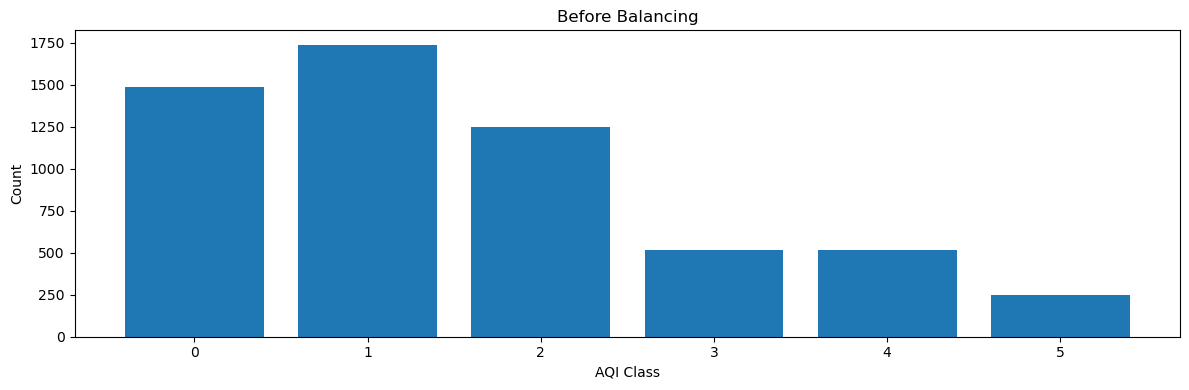

In [5]:
# ============================================================
# CLASS DISTRIBUTION CHECK (BEFORE BALANCING)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

def plot_class_distribution(y_before, y_after=None, title_before="Before Balancing", title_after="After Balancing"):
    fig, axes = plt.subplots(1, 2 if y_after is not None else 1, figsize=(12, 4))

    if y_after is None:
        axes = [axes]

    before_counts = pd.Series(y_before).value_counts().sort_index()
    axes[0].bar(before_counts.index.astype(str), before_counts.values)
    axes[0].set_title(title_before)
    axes[0].set_xlabel("AQI Class")
    axes[0].set_ylabel("Count")

    if y_after is not None:
        after_counts = pd.Series(y_after).value_counts().sort_index()
        axes[1].bar(after_counts.index.astype(str), after_counts.values)
        axes[1].set_title(title_after)
        axes[1].set_xlabel("AQI Class")
        axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

print("Original training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

plot_class_distribution(y_train)

Training split class distribution BEFORE balancing:
0    1190
1    1389
2     997
3     415
4     414
5     199
Name: count, dtype: int64

Original training split counts:
0    1190
1    1389
2     997
3     415
4     414
5     199
Name: count, dtype: int64

Under-sampling strategy: {np.int64(0): 900, np.int64(1): 900, np.int64(2): 900}
Over-sampling strategy : {np.int64(3): 900, np.int64(4): 900, np.int64(5): 900}

Training split class distribution AFTER HYBRID BALANCING (900 each):
0    900
1    900
2    900
3    900
4    900
5    900
Name: count, dtype: int64


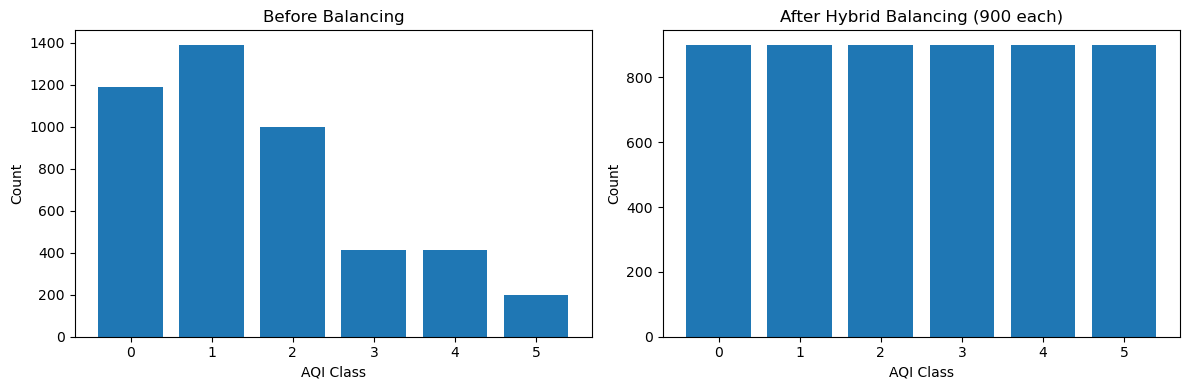

Training ML model: LogReg
Training ML model: SVM
Training ML model: XGBoost
Training ML model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000425 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 5400, number of used features: 6
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [6]:
# ============================================================
# TRAINING CELL REQUIRED BEFORE EVALUATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. TRAIN / VALIDATION SPLIT
# ============================================================
X_tr_ml, X_val_ml, y_tr, y_val = train_test_split(
    X_train_ml, y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

X_tr_dl = X_tr_ml.reshape((X_tr_ml.shape[0], 1, X_tr_ml.shape[1]))
X_val_dl = X_val_ml.reshape((X_val_ml.shape[0], 1, X_val_ml.shape[1]))

# ============================================================
# NEW BLOCK: SHOW CLASS DISTRIBUTION BEFORE BALANCING
# ============================================================
print("Training split class distribution BEFORE balancing:")
print(pd.Series(y_tr).value_counts().sort_index())

# ============================================================
# NEW BLOCK: APPLY SMOTE OR ADASYN
# Use only ONE at a time
# ============================================================

# ============================================================
# HYBRID BALANCING TO 900 PER CLASS
# Under-sampling for classes > 900
# Over-sampling (SMOTE) for classes < 900
# ============================================================

target_count = 900

print("\nOriginal training split counts:")
print(pd.Series(y_tr).value_counts().sort_index())

class_counts = Counter(y_tr)

under_strategy = {}
over_strategy = {}

for cls, count in sorted(class_counts.items()):
    if count > target_count:
        under_strategy[cls] = target_count
    elif count < target_count:
        over_strategy[cls] = target_count

print("\nUnder-sampling strategy:", under_strategy)
print("Over-sampling strategy :", over_strategy)

steps = []

# Step A: reduce majority classes to 900
if len(under_strategy) > 0:
    steps.append(
        ("under", RandomUnderSampler(
            sampling_strategy=under_strategy,
            random_state=SEED
        ))
    )

# Step B: increase minority classes to 900
if len(over_strategy) > 0:
    steps.append(
        ("over", SMOTE(
            sampling_strategy=over_strategy,
            random_state=SEED,
            k_neighbors=5
        ))
    )

hybrid_sampler = Pipeline(steps=steps)

X_tr_ml_bal, y_tr_bal = hybrid_sampler.fit_resample(X_tr_ml, y_tr)

print("\nTraining split class distribution AFTER HYBRID BALANCING (900 each):")
print(pd.Series(y_tr_bal).value_counts().sort_index())

plot_class_distribution(
    y_tr,
    y_tr_bal,
    "Before Balancing",
    "After Hybrid Balancing (900 each)"
)
# 3. TRAIN ML MODELS
# ============================================================
trained_ml = {}

ml_models = {
    "LogReg": LogisticRegression(max_iter=3000, random_state=SEED),
    "SVM": SVC(probability=True, random_state=SEED),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=SEED
    ),
    "LightGBM": LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED
)
}

for name, model in ml_models.items():
    print(f"Training ML model: {name}")
    model.fit(X_tr_ml_bal, y_tr_bal)
    trained_ml[name] = model
# ============================================================
# NEW BLOCK: TABNET TRAINING
# ============================================================
tabnet_model = TabNetClassifier(seed=SEED, verbose=0)

print("Training TabNet...")
tabnet_model.fit(
    X_tr_ml_bal, y_tr_bal,
    eval_set=[(X_val_ml, y_val)],
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=100,
    patience=15,
    batch_size=256,
    virtual_batch_size=128
)

trained_ml["TabNet"] = tabnet_model

# ============================================================
# NEW BLOCK: HYBRID MODEL (STACKING)
# ============================================================
trained_hybrid = {}

hybrid_model = StackingClassifier(
    estimators=[
        ("lgbm", LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=31,
            random_state=SEED
        )),
        ("xgb", xgb.XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=SEED
        )),
        ("svm", SVC(probability=True, random_state=SEED))
    ],
    final_estimator=LogisticRegression(max_iter=3000, random_state=SEED),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

print("Training Hybrid Stacking Model...")
hybrid_model.fit(X_tr_ml_bal, y_tr_bal)

trained_hybrid["Stacking_Hybrid"] = hybrid_model
print("Hybrid model trained successfully.")
# ============================================================
# 4. CREATE DL LOADERS
# ============================================================
X_tr_tensor = torch.tensor(X_tr_dl, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_dl, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ============================================================
# 5. DEFINE DL MODELS
# ============================================================
num_features = X_train_dl.shape[2]
num_classes = len(np.unique(y))

# ============================================================
# NEW/UPDATED: 1D CNN MODEL
# ============================================================
class CNN1DModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * input_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x[:, :1, :]
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class RNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_dim, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, num_classes, bidirectional=False):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=64,
            batch_first=True,
            bidirectional=bidirectional
        )
        mult = 2 if bidirectional else 1
        self.fc = nn.Linear(64 * mult, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

class GRUModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

# ============================================================
# NEW MODEL: TRANSFORMER
# ============================================================
class TransformerModel(nn.Module):
    def __init__(self, input_dim, num_classes, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        return self.fc(x)

dl_models = {
    "1D_CNN": CNN1DModel(num_features, num_classes).to(DEVICE),
    "LSTM": LSTMModel(num_features, num_classes, bidirectional=False).to(DEVICE),
    "BiLSTM": LSTMModel(num_features, num_classes, bidirectional=True).to(DEVICE),
    "GRU": GRUModel(num_features, num_classes).to(DEVICE),
    "Transformer": TransformerModel(num_features, num_classes).to(DEVICE)
}
# ============================================================
# NEW BLOCK: RESHAPE BALANCED DATA FOR DL
# ============================================================

X_tr_dl = X_tr_ml_bal.reshape((X_tr_ml_bal.shape[0], 1, X_tr_ml_bal.shape[1]))
X_val_dl = X_val_ml.reshape((X_val_ml.shape[0], 1, X_val_ml.shape[1]))
X_test_dl = X_test_ml.reshape((X_test_ml.shape[0], 1, X_test_ml.shape[1]))

X_tr_tensor = torch.tensor(X_tr_dl, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr_bal, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_dl, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_dl, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_tensor, y_tr_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

In [7]:
# ============================================================
# NEW CELL: VAE FOR DATA AUGMENTATION
# ============================================================
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 64)
        self.fc3 = nn.Linear(64, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld

input_dim = X_tr_ml_bal.shape[1]
latent_dim = 8

vae = VAE(input_dim=input_dim, latent_dim=latent_dim).to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

X_train_tensor_vae = torch.tensor(X_tr_ml_bal, dtype=torch.float32).to(DEVICE)

for epoch in range(100):
    vae.train()
    optimizer.zero_grad()
    recon, mu, logvar = vae(X_train_tensor_vae)
    loss = vae_loss(recon, X_train_tensor_vae, mu, logvar)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100, VAE Loss: {loss.item():.4f}")

Epoch 10/100, VAE Loss: 1.5016
Epoch 20/100, VAE Loss: 1.3479
Epoch 30/100, VAE Loss: 1.2278
Epoch 40/100, VAE Loss: 1.1086
Epoch 50/100, VAE Loss: 1.0163
Epoch 60/100, VAE Loss: 0.9518
Epoch 70/100, VAE Loss: 0.9064
Epoch 80/100, VAE Loss: 0.8728
Epoch 90/100, VAE Loss: 0.8494
Epoch 100/100, VAE Loss: 0.8330


Before augmentation: (5400, 6) (5400,)
After augmentation : (8100, 6) (8100,)


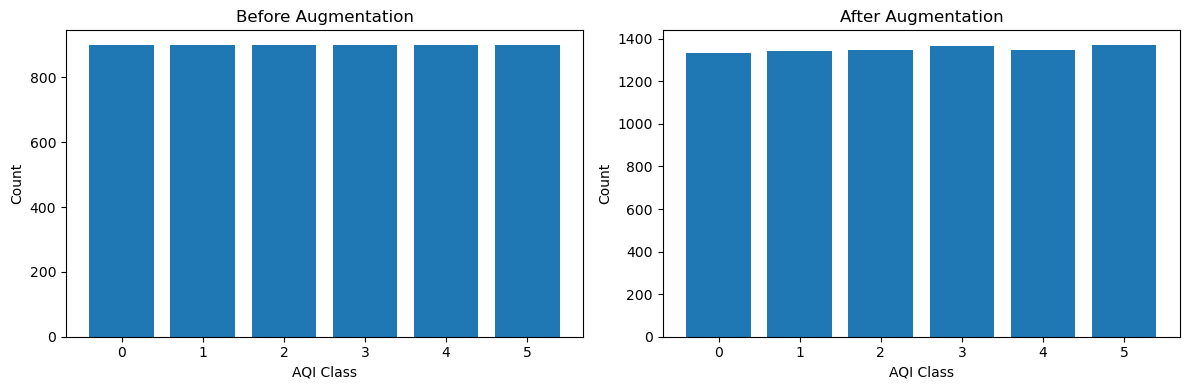

In [8]:
# ============================================================
# NEW CELL: GENERATE AUGMENTED DATA AND COMPARE
# ============================================================
vae.eval()

n_new = len(X_tr_ml_bal) // 2  # 50% extra samples

with torch.no_grad():
    z = torch.randn(n_new, latent_dim).to(DEVICE)
    synthetic_X = vae.decode(z).cpu().numpy()

synthetic_y = np.random.choice(y_tr_bal, size=n_new)

X_tr_aug = np.vstack([X_tr_ml_bal, synthetic_X])
y_tr_aug = np.hstack([y_tr_bal, synthetic_y])

print("Before augmentation:", X_tr_ml_bal.shape, y_tr_bal.shape)
print("After augmentation :", X_tr_aug.shape, y_tr_aug.shape)

plot_class_distribution(y_tr_bal, y_tr_aug, "Before Augmentation", "After Augmentation")

In [9]:
# ============================================================
# NEW CELL: RETRAIN SELECTED MODELS ON AUGMENTED DATA
# ============================================================
trained_aug = {}

# LightGBM on augmented data
lgbm_aug = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED
)
lgbm_aug.fit(X_tr_aug, y_tr_aug)
trained_aug["LightGBM_Aug"] = lgbm_aug

# XGBoost on augmented data
xgb_aug = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=SEED
)
xgb_aug.fit(X_tr_aug, y_tr_aug)
trained_aug["XGBoost_Aug"] = xgb_aug

print("Augmented models trained:", list(trained_aug.keys()))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 8100, number of used features: 6
[LightGBM] [Info] Start training from score -1.803682
[LightGBM] [Info] Start training from score -1.798448
[LightGBM] [Info] Start training from score -1.795470
[LightGBM] [Info] Start training from score -1.781443
[LightGBM] [Info] Start training from score -1.795470
[LightGBM] [Info] Start training from score -1.776324
Augmented models trained: ['LightGBM_Aug', 'XGBoost_Aug']


In [17]:
# ============================================================
# TRAIN DL MODELS
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(np.unique(y_train))
input_size = X_train_tensor.shape[2]

def train_dl_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total if total > 0 else 0
        print(f"{model.__class__.__name__} | Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

    return model

In [12]:
# ============================================================
# DL PREPARATION AFTER HYBRID BALANCING
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Reshape balanced training data for DL
X_tr_dl_bal = X_tr_ml_bal.reshape((X_tr_ml_bal.shape[0], 1, X_tr_ml_bal.shape[1]))
X_val_dl = X_val_ml.reshape((X_val_ml.shape[0], 1, X_val_ml.shape[1]))
X_test_dl = X_test_ml.reshape((X_test_ml.shape[0], 1, X_test_ml.shape[1]))

# Convert to tensors
X_train_tensor = torch.tensor(X_tr_dl_bal, dtype=torch.float32)
y_train_tensor = torch.tensor(y_tr_bal, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_dl, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_dl, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Build DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

print("DL loaders ready.")
print("Train tensor shape:", X_train_tensor.shape)
print("Validation tensor shape:", X_val_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)

DL loaders ready.
Train tensor shape: torch.Size([5400, 1, 6])
Validation tensor shape: torch.Size([1152, 1, 6])
Test tensor shape: torch.Size([1440, 1, 6])


In [22]:
# ============================================================
# CREATE AND TRAIN DL MODELS (FINAL FIXED VERSION)
# ============================================================

trained_dl = {}

# CNN
cnn_model = CNN1DModel(input_dim=input_size, num_classes=num_classes)
trained_dl["CNN"] = train_dl_model(cnn_model, train_loader, val_loader)

# RNN
rnn_model = RNNModel(input_dim=input_size, num_classes=num_classes)
trained_dl["RNN"] = train_dl_model(rnn_model, train_loader, val_loader)

# LSTM
lstm_model = LSTMModel(input_dim=input_size, num_classes=num_classes, bidirectional=False)
trained_dl["LSTM"] = train_dl_model(lstm_model, train_loader, val_loader)

# BiLSTM
bilstm_model = LSTMModel(input_dim=input_size, num_classes=num_classes, bidirectional=True)
trained_dl["BiLSTM"] = train_dl_model(bilstm_model, train_loader, val_loader)

# GRU
gru_model = GRUModel(input_dim=input_size, num_classes=num_classes)
trained_dl["GRU"] = train_dl_model(gru_model, train_loader, val_loader)

print("DL models trained:", trained_dl.keys())

CNN1DModel | Epoch 1/20 | Train Loss: 0.7160 | Val Loss: 0.3559 | Val Acc: 0.8828
CNN1DModel | Epoch 2/20 | Train Loss: 0.3024 | Val Loss: 0.3484 | Val Acc: 0.8802
CNN1DModel | Epoch 3/20 | Train Loss: 0.2471 | Val Loss: 0.2641 | Val Acc: 0.9314
CNN1DModel | Epoch 4/20 | Train Loss: 0.2271 | Val Loss: 0.2247 | Val Acc: 0.9384
CNN1DModel | Epoch 5/20 | Train Loss: 0.1974 | Val Loss: 0.2613 | Val Acc: 0.9297
CNN1DModel | Epoch 6/20 | Train Loss: 0.1808 | Val Loss: 0.2187 | Val Acc: 0.9401
CNN1DModel | Epoch 7/20 | Train Loss: 0.1692 | Val Loss: 0.2256 | Val Acc: 0.9349
CNN1DModel | Epoch 8/20 | Train Loss: 0.1585 | Val Loss: 0.2024 | Val Acc: 0.9505
CNN1DModel | Epoch 9/20 | Train Loss: 0.1469 | Val Loss: 0.1742 | Val Acc: 0.9505
CNN1DModel | Epoch 10/20 | Train Loss: 0.1406 | Val Loss: 0.1892 | Val Acc: 0.9514
CNN1DModel | Epoch 11/20 | Train Loss: 0.1291 | Val Loss: 0.1581 | Val Acc: 0.9627
CNN1DModel | Epoch 12/20 | Train Loss: 0.1319 | Val Loss: 0.1654 | Val Acc: 0.9514
CNN1DModel | 


================ ML MODELS =================

LogReg
Accuracy : 0.8826
Precision: 0.8853
Recall   : 0.8826
F1 Score : 0.8831
ROC-AUC  : 0.9861

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       372
           1       0.92      0.85      0.88       435
           2       0.84      0.82      0.83       312
           3       0.70      0.81      0.75       130
           4       0.91      0.95      0.93       129
           5       0.98      0.98      0.98        62

    accuracy                           0.88      1440
   macro avg       0.88      0.89      0.89      1440
weighted avg       0.89      0.88      0.88      1440


Confusion Matrix Values:
[[356  15   1   0   0   0]
 [ 30 370  34   1   0   0]
 [  0  16 257  37   2   0]
 [  0   2  13 105   9   1]
 [  0   0   0   7 122   0]
 [  0   0   0   0   1  61]]


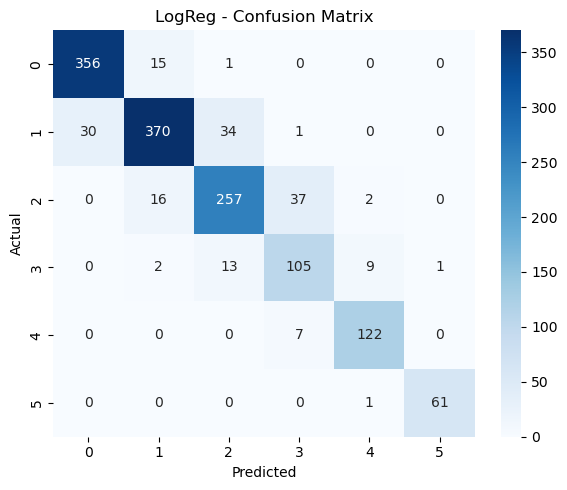


SVM
Accuracy : 0.8972
Precision: 0.9015
Recall   : 0.8972
F1 Score : 0.8983
ROC-AUC  : 0.9908

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       372
           1       0.94      0.88      0.91       435
           2       0.87      0.85      0.86       312
           3       0.70      0.85      0.77       130
           4       0.89      0.89      0.89       129
           5       0.94      0.94      0.94        62

    accuracy                           0.90      1440
   macro avg       0.88      0.90      0.89      1440
weighted avg       0.90      0.90      0.90      1440


Confusion Matrix Values:
[[359  13   0   0   0   0]
 [ 21 384  29   1   0   0]
 [  0   9 265  35   3   0]
 [  0   1   9 111   8   1]
 [  0   0   0  11 115   3]
 [  0   0   1   0   3  58]]


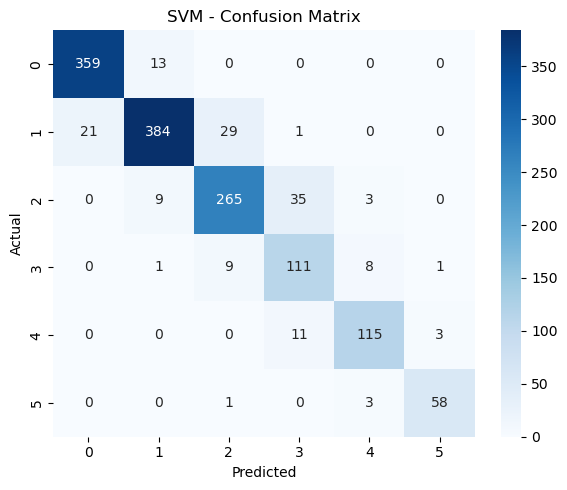


XGBoost
Accuracy : 0.9875
Precision: 0.9877
Recall   : 0.9875
F1 Score : 0.9875
ROC-AUC  : 0.9997

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       372
           1       1.00      0.99      0.99       435
           2       1.00      0.98      0.99       312
           3       0.96      0.98      0.97       130
           4       0.95      0.98      0.97       129
           5       0.98      0.98      0.98        62

    accuracy                           0.99      1440
   macro avg       0.98      0.99      0.98      1440
weighted avg       0.99      0.99      0.99      1440


Confusion Matrix Values:
[[370   2   0   0   0   0]
 [  4 430   0   0   1   0]
 [  0   0 306   3   3   0]
 [  0   0   0 128   1   1]
 [  0   0   0   2 127   0]
 [  0   0   0   0   1  61]]


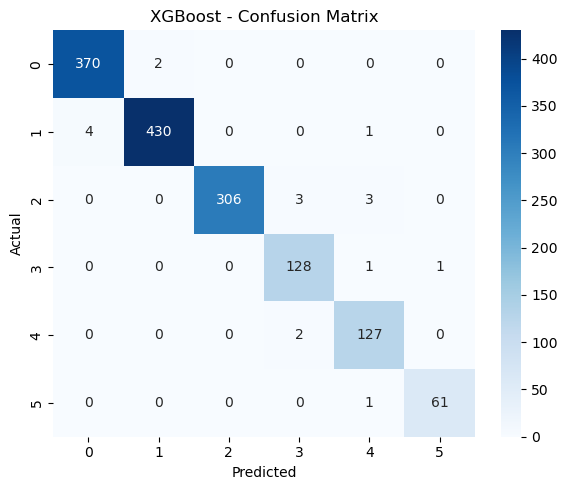


LightGBM
Accuracy : 0.9819
Precision: 0.9821
Recall   : 0.9819
F1 Score : 0.9820
ROC-AUC  : 0.9998

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       372
           1       0.99      0.98      0.99       435
           2       0.98      0.97      0.97       312
           3       0.96      0.99      0.97       130
           4       0.96      0.97      0.97       129
           5       0.98      0.98      0.98        62

    accuracy                           0.98      1440
   macro avg       0.98      0.98      0.98      1440
weighted avg       0.98      0.98      0.98      1440


Confusion Matrix Values:
[[370   1   1   0   0   0]
 [  4 427   3   0   1   0]
 [  0   2 302   5   3   0]
 [  0   0   1 129   0   0]
 [  0   0   2   1 125   1]
 [  0   0   0   0   1  61]]


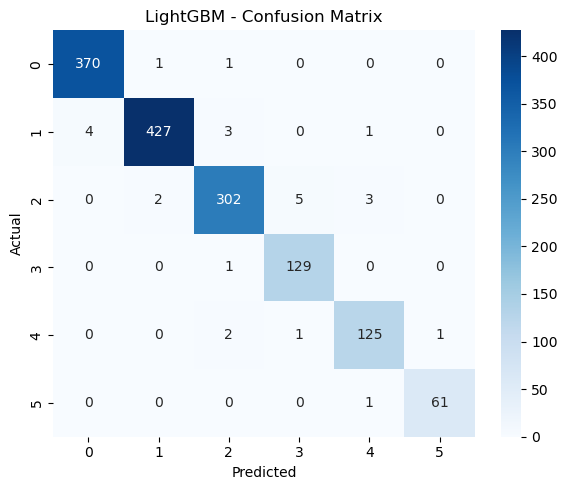


================ TABNET =================

TabNet
Accuracy : 0.9625
Precision: 0.9632
Recall   : 0.9625
F1 Score : 0.9627
ROC-AUC  : 0.9974

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       372
           1       0.98      0.96      0.97       435
           2       0.95      0.95      0.95       312
           3       0.88      0.94      0.91       130
           4       0.97      0.95      0.96       129
           5       0.98      0.97      0.98        62

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440


Confusion Matrix Values:
[[369   2   1   0   0   0]
 [  9 417   8   0   1   0]
 [  0   5 296  10   1   0]
 [  0   0   7 122   0   1]
 [  0   0   0   7 122   0]
 [  0   0   0   0   2  60]]


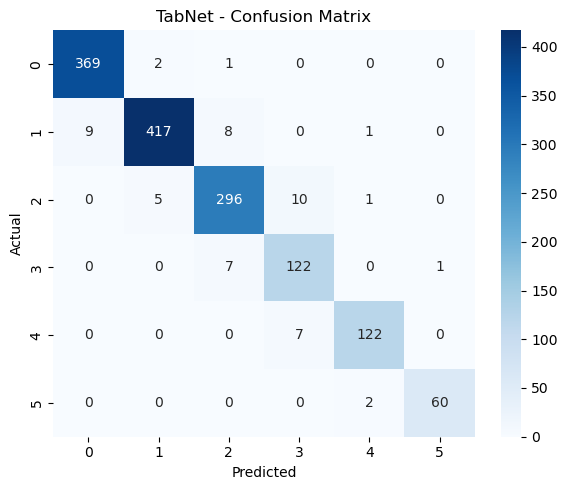


================ DL MODELS =================

CNN
Accuracy : 0.9431
Precision: 0.9450
Recall   : 0.9431
F1 Score : 0.9429
ROC-AUC  : 0.9974

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       372
           1       0.99      0.92      0.95       435
           2       0.90      0.96      0.93       312
           3       0.93      0.86      0.89       130
           4       0.88      0.99      0.93       129
           5       0.96      0.84      0.90        62

    accuracy                           0.94      1440
   macro avg       0.94      0.93      0.93      1440
weighted avg       0.95      0.94      0.94      1440


Confusion Matrix Values:
[[368   3   1   0   0   0]
 [ 15 400  19   0   1   0]
 [  0   3 298   8   3   0]
 [  0   0  13 112   4   1]
 [  0   0   0   0 128   1]
 [  0   0   0   1   9  52]]


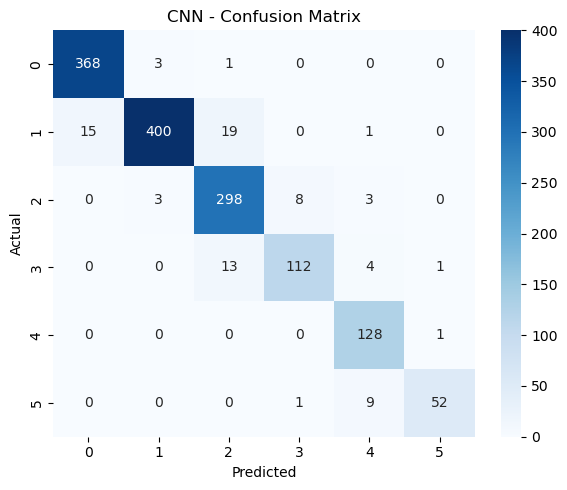


RNN
Accuracy : 0.8993
Precision: 0.9025
Recall   : 0.8993
F1 Score : 0.8998
ROC-AUC  : 0.9889

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       372
           1       0.95      0.87      0.91       435
           2       0.87      0.85      0.86       312
           3       0.70      0.80      0.75       130
           4       0.91      0.95      0.93       129
           5       0.95      0.98      0.97        62

    accuracy                           0.90      1440
   macro avg       0.89      0.90      0.89      1440
weighted avg       0.90      0.90      0.90      1440


Confusion Matrix Values:
[[364   7   0   1   0   0]
 [ 30 380  24   1   0   0]
 [  0   9 264  37   2   0]
 [  0   2  14 104   9   1]
 [  0   0   0   5 122   2]
 [  0   0   0   0   1  61]]


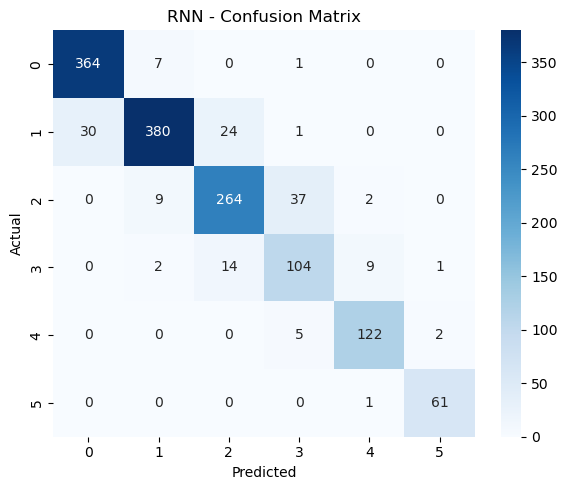


LSTM
Accuracy : 0.9153
Precision: 0.9178
Recall   : 0.9153
F1 Score : 0.9159
ROC-AUC  : 0.9913

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95       372
           1       0.92      0.95      0.93       435
           2       0.91      0.88      0.89       312
           3       0.75      0.80      0.77       130
           4       0.89      0.96      0.92       129
           5       0.98      0.97      0.98        62

    accuracy                           0.92      1440
   macro avg       0.90      0.91      0.91      1440
weighted avg       0.92      0.92      0.92      1440


Confusion Matrix Values:
[[343  28   0   1   0   0]
 [  4 414  16   1   0   0]
 [  0   8 273  28   3   0]
 [  0   2  12 104  11   1]
 [  0   0   0   5 124   0]
 [  0   0   0   0   2  60]]


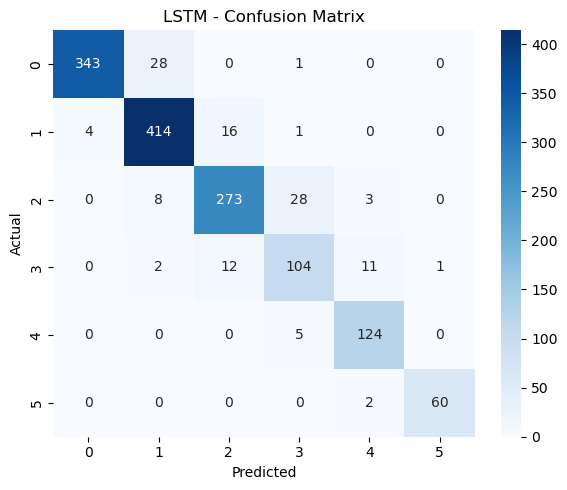


BiLSTM
Accuracy : 0.9271
Precision: 0.9280
Recall   : 0.9271
F1 Score : 0.9274
ROC-AUC  : 0.9926

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       372
           1       0.94      0.94      0.94       435
           2       0.90      0.91      0.91       312
           3       0.80      0.81      0.80       130
           4       0.91      0.95      0.93       129
           5       0.97      0.97      0.97        62

    accuracy                           0.93      1440
   macro avg       0.92      0.92      0.92      1440
weighted avg       0.93      0.93      0.93      1440


Confusion Matrix Values:
[[352  18   1   1   0   0]
 [  6 410  18   1   0   0]
 [  0   6 285  20   1   0]
 [  0   2  13 105   9   1]
 [  0   0   0   5 123   1]
 [  0   0   0   0   2  60]]


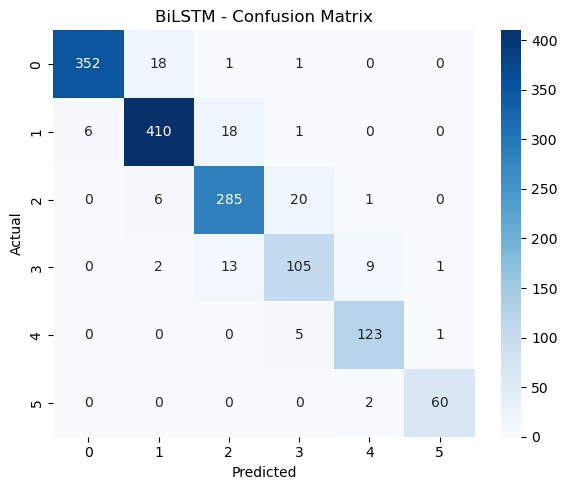


GRU
Accuracy : 0.9153
Precision: 0.9152
Recall   : 0.9153
F1 Score : 0.9151
ROC-AUC  : 0.9908

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       372
           1       0.94      0.92      0.93       435
           2       0.89      0.89      0.89       312
           3       0.78      0.75      0.77       130
           4       0.89      0.93      0.91       129
           5       0.92      0.98      0.95        62

    accuracy                           0.92      1440
   macro avg       0.90      0.91      0.90      1440
weighted avg       0.92      0.92      0.92      1440


Confusion Matrix Values:
[[358  13   0   1   0   0]
 [ 15 402  17   1   0   0]
 [  0   9 279  21   3   0]
 [  0   2  18  98  11   1]
 [  0   0   0   5 120   4]
 [  0   0   0   0   1  61]]


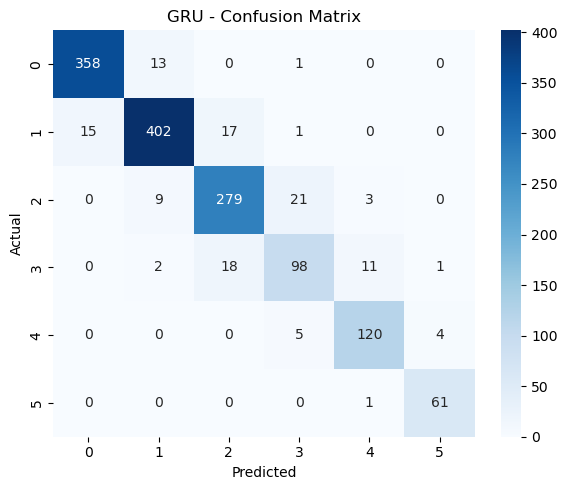


================ HYBRID MODELS =================

Stacking_Hybrid
Accuracy : 0.9854
Precision: 0.9856
Recall   : 0.9854
F1 Score : 0.9855
ROC-AUC  : 0.9993

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       372
           1       0.99      0.99      0.99       435
           2       0.99      0.98      0.99       312
           3       0.96      0.98      0.97       130
           4       0.95      0.98      0.97       129
           5       0.98      0.98      0.98        62

    accuracy                           0.99      1440
   macro avg       0.98      0.98      0.98      1440
weighted avg       0.99      0.99      0.99      1440


Confusion Matrix Values:
[[369   3   0   0   0   0]
 [  3 429   2   0   1   0]
 [  0   0 305   4   3   0]
 [  0   0   0 128   1   1]
 [  0   0   0   2 127   0]
 [  0   0   0   0   1  61]]


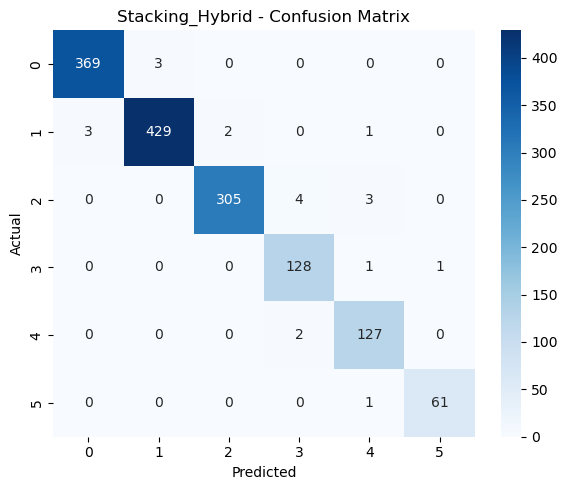


================ AUGMENTED MODELS =================

LightGBM_Aug
Accuracy : 0.9792
Precision: 0.9796
Recall   : 0.9792
F1 Score : 0.9792
ROC-AUC  : 0.9980

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       372
           1       0.99      0.98      0.98       435
           2       0.99      0.96      0.97       312
           3       0.93      0.98      0.96       130
           4       0.96      0.99      0.98       129
           5       0.94      0.97      0.95        62

    accuracy                           0.98      1440
   macro avg       0.97      0.98      0.97      1440
weighted avg       0.98      0.98      0.98      1440


Confusion Matrix Values:
[[370   0   1   0   1   0]
 [  4 425   2   0   1   3]
 [  1   3 299   9   0   0]
 [  1   0   0 128   1   0]
 [  0   0   0   0 128   1]
 [  0   0   0   0   2  60]]


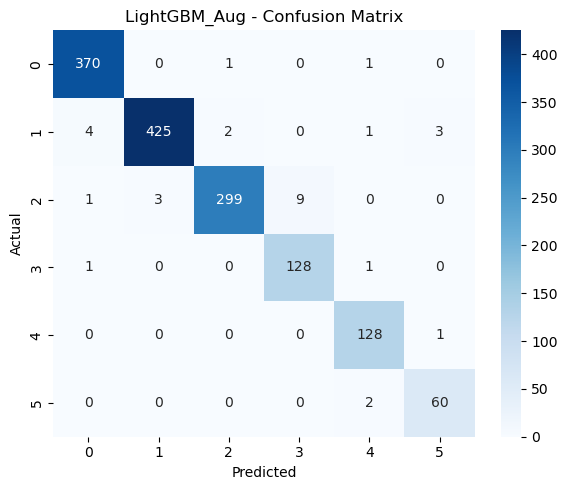


XGBoost_Aug
Accuracy : 0.9819
Precision: 0.9823
Recall   : 0.9819
F1 Score : 0.9820
ROC-AUC  : 0.9984

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       372
           1       0.99      0.98      0.99       435
           2       0.99      0.97      0.98       312
           3       0.93      0.98      0.96       130
           4       0.97      0.98      0.97       129
           5       0.95      0.98      0.97        62

    accuracy                           0.98      1440
   macro avg       0.97      0.98      0.98      1440
weighted avg       0.98      0.98      0.98      1440


Confusion Matrix Values:
[[368   3   1   0   0   0]
 [  4 428   1   0   1   1]
 [  0   1 303   6   2   0]
 [  0   0   0 128   0   2]
 [  0   0   0   3 126   0]
 [  0   0   0   0   1  61]]


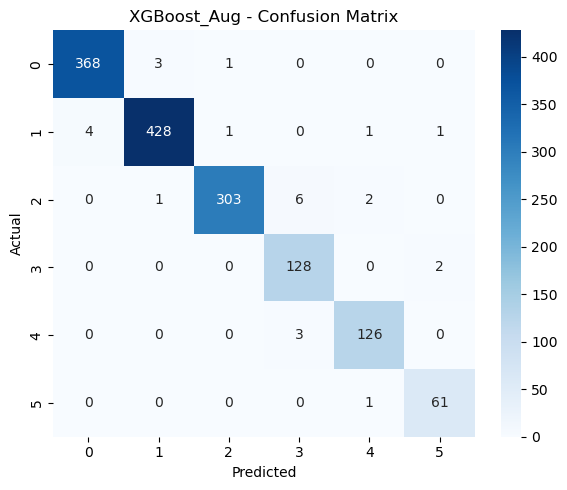


================ FINAL RESULTS =================
     Category            Model  Accuracy  Precision    Recall  F1 Score  \
2          ML          XGBoost  0.987500   0.987709  0.987500  0.987547   
10     Hybrid  Stacking_Hybrid  0.985417   0.985629  0.985417  0.985465   
12  Augmented      XGBoost_Aug  0.981944   0.982299  0.981944  0.982019   
3          ML         LightGBM  0.981944   0.982069  0.981944  0.981957   
11  Augmented     LightGBM_Aug  0.979167   0.979619  0.979167  0.979219   
4      TabNet           TabNet  0.962500   0.963160  0.962500  0.962659   
5          DL              CNN  0.943056   0.945005  0.943056  0.942884   
8          DL           BiLSTM  0.927083   0.927967  0.927083  0.927373   
7          DL             LSTM  0.915278   0.917795  0.915278  0.915853   
9          DL              GRU  0.915278   0.915165  0.915278  0.915089   
6          DL              RNN  0.899306   0.902525  0.899306  0.899794   
1          ML              SVM  0.897222   0.90150

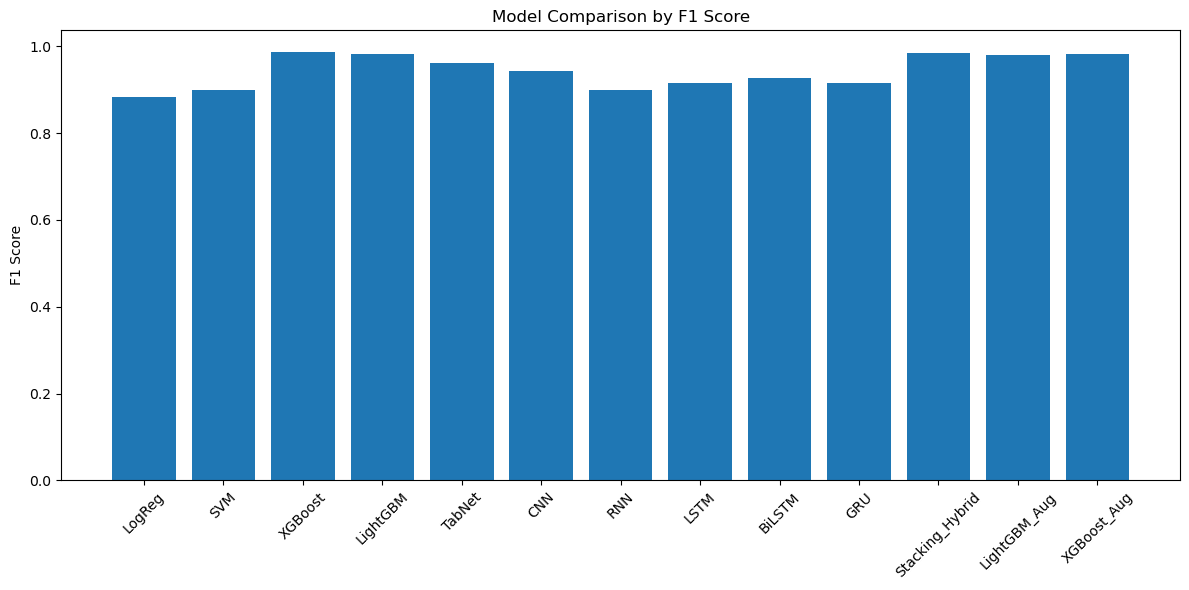

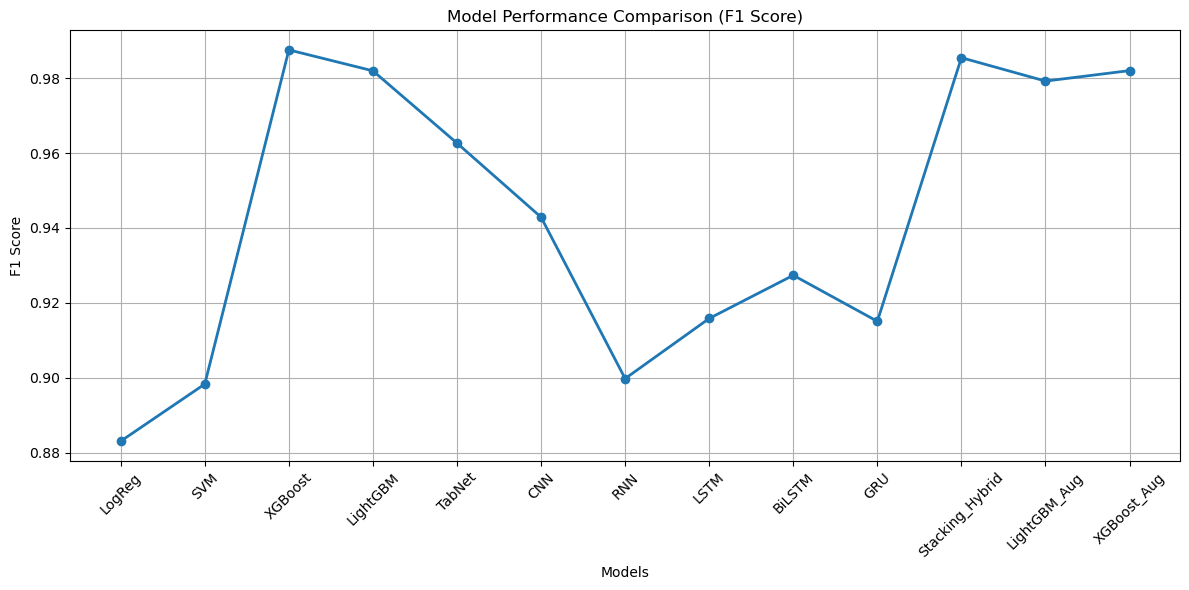

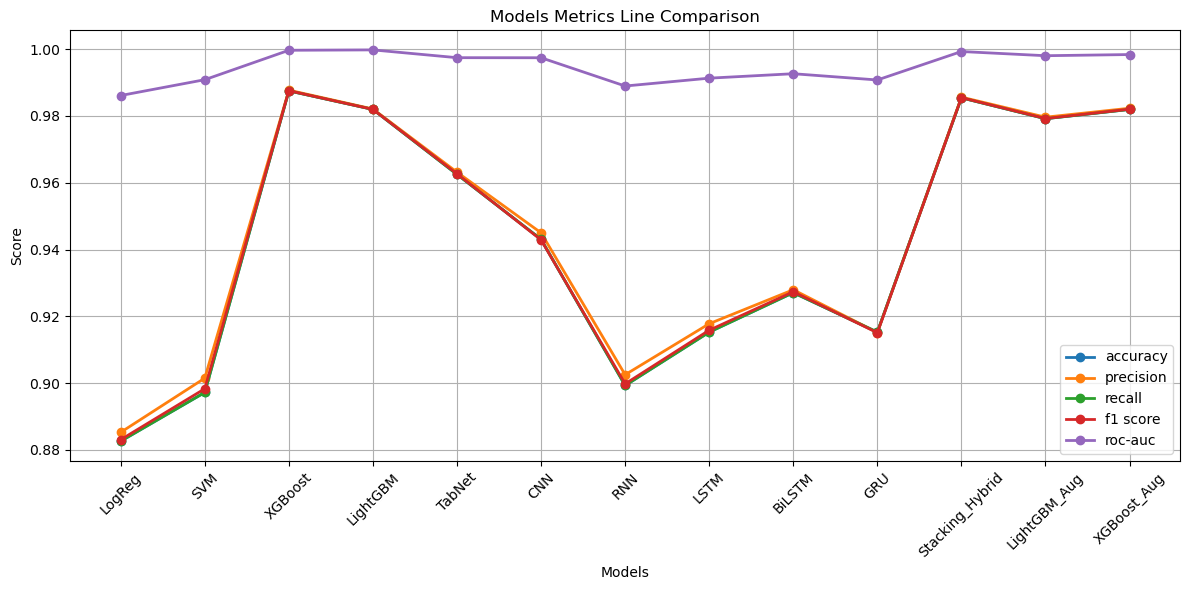

In [25]:
# ============================================================
# UPDATED EVALUATION CELL
# WITH CONFUSION MATRIX DIAGRAM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# ============================================================
# HELPER FUNCTION: SAFE ROC-AUC
# ============================================================
def safe_multiclass_roc_auc(y_true, y_prob):
    try:
        y_true_dummies = pd.get_dummies(pd.Series(y_true))
        y_true_dummies = y_true_dummies.reindex(columns=range(y_prob.shape[1]), fill_value=0)
        return roc_auc_score(y_true_dummies, y_prob, multi_class='ovr')
    except Exception:
        return None


# ============================================================
# HELPER FUNCTION: CONFUSION MATRIX PLOT
# ============================================================
def plot_confusion_matrix(cm, model_name):

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


# ============================================================
# STORE RESULTS
# ============================================================
all_results = []

def add_result(model_name, y_true, y_pred, y_prob=None, category="Model"):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    auc = safe_multiclass_roc_auc(y_true, y_prob) if y_prob is not None else None

    all_results.append({
        "Category": category,
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

    print("\n====================================================")
    print(model_name)
    print("====================================================")

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if auc is not None:
        print(f"ROC-AUC  : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix Values:")
    print(cm)

    plot_confusion_matrix(cm, model_name)


# ============================================================
# 1. EVALUATE ML MODELS
# ============================================================
print("\n================ ML MODELS =================")

if 'trained_ml' in globals():

    for name, model in trained_ml.items():

        if name == "TabNet":
            continue

        try:
            y_pred = model.predict(X_test_ml)

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test_ml)
            else:
                y_prob = None

            add_result(name, y_test, y_pred, y_prob, "ML")

        except Exception as e:
            print("Error evaluating", name, e)


# ============================================================
# 2. EVALUATE TABNET
# ============================================================
print("\n================ TABNET =================")

if 'trained_ml' in globals() and "TabNet" in trained_ml:

    tabnet_model = trained_ml["TabNet"]

    y_pred = tabnet_model.predict(X_test_ml).reshape(-1)

    try:
        y_prob = tabnet_model.predict_proba(X_test_ml)
    except:
        y_prob = None

    add_result("TabNet", y_test, y_pred, y_prob, "TabNet")


# ============================================================
# 3. EVALUATE DL MODELS
# ============================================================
print("\n================ DL MODELS =================")

def evaluate_dl_model(model, name, test_loader):

    model.eval()

    preds = []
    trues = []
    probs = []

    with torch.no_grad():

        for xb, yb in test_loader:

            xb = xb.to(DEVICE)

            outputs = model(xb)

            prob = torch.softmax(outputs, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)

            probs.extend(prob)
            preds.extend(pred)
            trues.extend(yb.numpy())

    add_result(name, np.array(trues), np.array(preds), np.array(probs), "DL")


if 'trained_dl' in globals():

    for name, model in trained_dl.items():

        try:
            evaluate_dl_model(model, name, test_loader)

        except Exception as e:
            print("Error evaluating", name, e)


# ============================================================
# 4. EVALUATE HYBRID MODEL
# ============================================================
print("\n================ HYBRID MODELS =================")

if 'trained_hybrid' in globals():

    for name, model in trained_hybrid.items():

        try:

            y_pred = model.predict(X_test_ml)

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test_ml)
            else:
                y_prob = None

            add_result(name, y_test, y_pred, y_prob, "Hybrid")

        except Exception as e:
            print("Error evaluating hybrid", e)


# ============================================================
# 5. EVALUATE AUGMENTED MODELS
# ============================================================
print("\n================ AUGMENTED MODELS =================")

if 'trained_aug' in globals():

    for name, model in trained_aug.items():

        try:

            y_pred = model.predict(X_test_ml)

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test_ml)
            else:
                y_prob = None

            add_result(name, y_test, y_pred, y_prob, "Augmented")

        except Exception as e:
            print("Error evaluating", name, e)


# ============================================================
# FINAL RESULTS TABLE
# ============================================================
results_df = pd.DataFrame(all_results)

print("\n================ FINAL RESULTS =================")

print(results_df.sort_values("F1 Score", ascending=False))


# ============================================================
# BEST MODEL
# ============================================================
best_row = results_df.sort_values("F1 Score", ascending=False).iloc[0]

print("\n================ BEST MODEL =================")
print("Model:", best_row["Model"])
print("Category:", best_row["Category"])
print("F1 Score:", best_row["F1 Score"])


# ============================================================
# MODEL COMPARISON GRAPH
# ============================================================
plt.figure(figsize=(12,6))

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.xticks(rotation=45)

plt.title("Model Comparison by F1 Score")

plt.ylabel("F1 Score")

plt.tight_layout()

plt.show()

# ============================================================
# LINE CHART COMPARISON OF MODELS
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    results_df["Model"],
    results_df["F1 Score"],
    marker='o',
    linewidth=2
)

plt.title("Model Performance Comparison (F1 Score)")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# MULTI-METRIC LINE CHART COMPARISON (LIKE OLD CODE)
# ============================================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

# ROC-AUC may contain None for some models
if "ROC-AUC" in results_df.columns:
    metrics.append("ROC-AUC")

models = results_df["Model"]

plt.figure(figsize=(12,6))

for metric in metrics:
    
    values = results_df[metric]
    
    plt.plot(
        models,
        values,
        marker='o',
        linewidth=2,
        label=metric.lower()
    )

plt.title("Models Metrics Line Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


✅ ML XAI (SHAP) Importance Table:
                PM2.5      PM10       NO2       SO2        CO     Ozone
ML-LogReg    0.576743  0.395414  0.007881  0.009259  0.005409  0.005294
ML-XGBoost   0.500110  0.435927  0.018749  0.014146  0.012734  0.018335
ML-LightGBM  0.503056  0.432789  0.015989  0.016046  0.014970  0.017150
ML-SVM       0.354643  0.553250  0.028627  0.017758  0.019401  0.026321
ML-TabNet    0.377852  0.601709  0.006452  0.002353  0.001164  0.010470


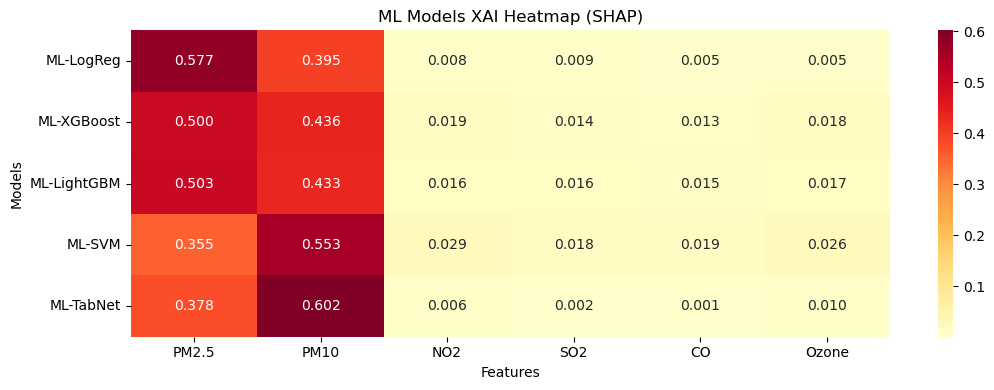


✅ Augmented Models XAI (SHAP) Importance Table:
                 PM2.5      PM10       NO2       SO2        CO     Ozone
AUG-LightGBM  0.304816  0.373401  0.081721  0.063446  0.104148  0.072468
AUG-XGBoost   0.351261  0.383616  0.070234  0.047547  0.081858  0.065484


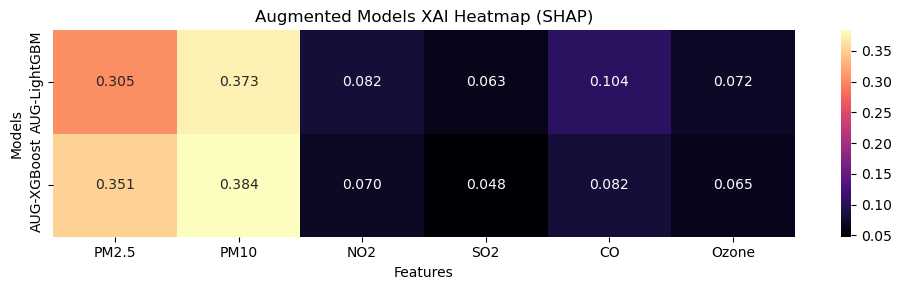


✅ DL XAI (Integrated Gradients) Importance Table:
              PM2.5      PM10       NO2       SO2        CO     Ozone
DL-CNN     0.484632  0.427817  0.019333  0.023082  0.024826  0.020311
DL-RNN     0.481711  0.497011  0.004643  0.006775  0.003273  0.006587
DL-LSTM    0.361586  0.448067  0.045977  0.043783  0.029481  0.071106
DL-BiLSTM  0.379657  0.438704  0.048878  0.038529  0.031624  0.062607
DL-GRU     0.388542  0.468440  0.031828  0.031934  0.023787  0.055469


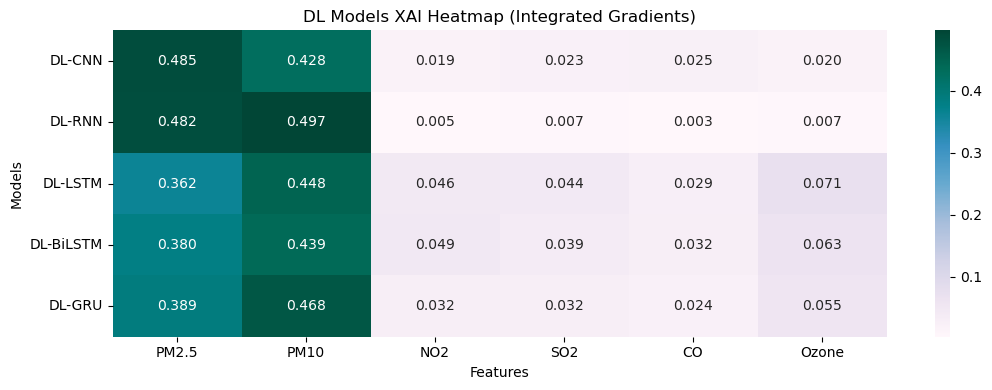

  0%|          | 0/120 [00:00<?, ?it/s]


✅ Hybrid XAI (SHAP) Importance Table:
                    PM2.5     PM10       NO2      SO2        CO     Ozone
Hybrid-Stacking  0.442833  0.54364  0.003112  0.00241  0.002341  0.005665


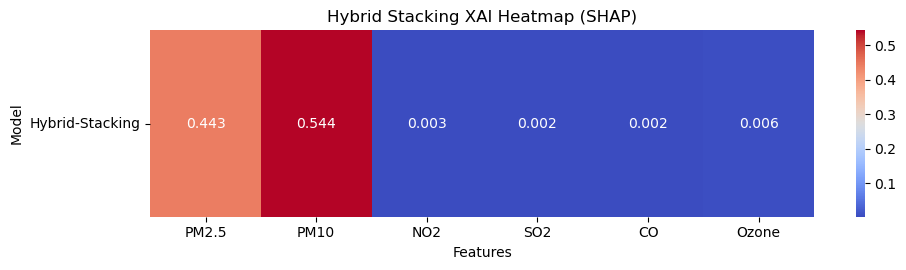

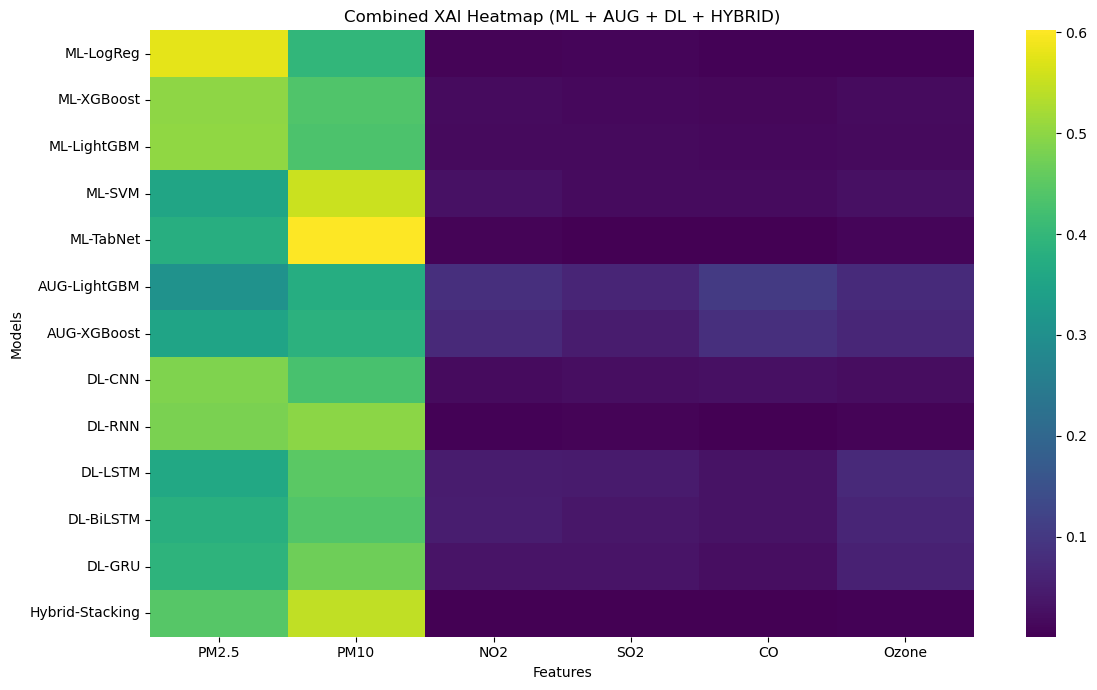

In [24]:
# ============================================================
# FINAL XAI BLOCK (UPDATED WORKFLOW): ML + DL + HYBRID + AUG
# OUTPUT: HEATMAPS
# ============================================================

import numpy as np
import pandas as pd[

import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch
from captum.attr import IntegratedGradients

# ============================================================
# REQUIRED VARIABLES EXPECTED FROM PREVIOUS CELLS
# ============================================================
# X_train_ml
# X_test_ml
# y_test
# trained_ml
# trained_dl
# trained_hybrid
# trained_aug
# DEVICE

# ============================================================
# FEATURE NAMES
# ============================================================
if "feature_cols" in globals():
    feature_names = list(feature_cols)
else:
    feature_names = ["PM2.5", "PM10", "NO2", "SO2", "CO", "Ozone"]

num_classes = len(np.unique(y_test))

# ============================================================
# BUILD DATAFRAMES FOR SHAP
# ============================================================
X_train_df = pd.DataFrame(X_train_ml, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_ml, columns=feature_names)

# ============================================================
# CREATE X_test_dl IF NOT ALREADY PRESENT
# ============================================================
if "X_test_dl" not in globals():
    X_test_dl = X_test_ml.reshape((X_test_ml.shape[0], 1, X_test_ml.shape[1]))

# ============================================================
# HELPER: GLOBAL SHAP IMPORTANCE
# ============================================================
def global_shap_importance(shap_vals):
    """
    Return mean absolute SHAP importance per feature.
    Works for:
    - list of arrays
    - 2D arrays
    - 3D arrays
    """
    if isinstance(shap_vals, list):
        arrs = [np.abs(v).mean(axis=0) for v in shap_vals]
        return np.mean(arrs, axis=0)

    shap_vals = np.array(shap_vals)

    if shap_vals.ndim == 3:
        return np.abs(shap_vals).mean(axis=(0, 2))
    elif shap_vals.ndim == 2:
        return np.abs(shap_vals).mean(axis=0)
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_vals.shape}")

# ============================================================
# 1) ML XAI (SHAP)
# ============================================================
ml_xai_rows = {}

# ---------------------------
# Logistic Regression
# ---------------------------
if "trained_ml" in globals() and "LogReg" in trained_ml:
    try:
        model = trained_ml["LogReg"]
        explainer = shap.LinearExplainer(model, X_train_df)
        shap_values = explainer.shap_values(X_test_df)
        ml_xai_rows["ML-LogReg"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ ML-LogReg SHAP skipped: {e}")

# ---------------------------
# XGBoost
# ---------------------------
if "trained_ml" in globals() and "XGBoost" in trained_ml:
    try:
        model = trained_ml["XGBoost"]
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_df)
        ml_xai_rows["ML-XGBoost"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ ML-XGBoost SHAP skipped: {e}")

# ---------------------------
# LightGBM
# ---------------------------
if "trained_ml" in globals() and "LightGBM" in trained_ml:
    try:
        model = trained_ml["LightGBM"]
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_df)
        ml_xai_rows["ML-LightGBM"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ ML-LightGBM SHAP skipped: {e}")

# ---------------------------
# SVM
# ---------------------------
if "trained_ml" in globals() and "SVM" in trained_ml:
    try:
        model = trained_ml["SVM"]
        background = shap.sample(X_train_df, min(80, len(X_train_df)), random_state=42)
        X_explain   = shap.sample(X_test_df, min(120, len(X_test_df)), random_state=42)

        explainer = shap.KernelExplainer(model.predict_proba, background)
        shap_values = explainer.shap_values(X_explain)

        ml_xai_rows["ML-SVM"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ ML-SVM SHAP skipped: {e}")

# ---------------------------
# TabNet
# ---------------------------
if "trained_ml" in globals() and "TabNet" in trained_ml:
    try:
        model = trained_ml["TabNet"]
        background = shap.sample(X_train_df, min(80, len(X_train_df)), random_state=42)
        X_explain   = shap.sample(X_test_df, min(120, len(X_test_df)), random_state=42)

        explainer = shap.KernelExplainer(model.predict_proba, background.to_numpy())
        shap_values = explainer.shap_values(X_explain.to_numpy())

        ml_xai_rows["ML-TabNet"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ ML-TabNet SHAP skipped: {e}")

# ---------------------------
# ML Heatmap
# ---------------------------
if len(ml_xai_rows) > 0:
    ml_xai_df = pd.DataFrame(ml_xai_rows, index=feature_names).T
    ml_xai_df = ml_xai_df.apply(lambda r: r / (r.sum() + 1e-9), axis=1)

    print("\n✅ ML XAI (SHAP) Importance Table:")
    print(ml_xai_df)

    plt.figure(figsize=(11, 4))
    sns.heatmap(ml_xai_df, annot=True, fmt=".3f", cmap="YlOrRd")
    plt.title("ML Models XAI Heatmap (SHAP)")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.tight_layout()
    plt.show()
else:
    ml_xai_df = pd.DataFrame()
    print("\n⚠️ No ML XAI heatmap generated.")

# ============================================================
# 2) AUGMENTED MODEL XAI (SHAP)
# ============================================================
aug_xai_rows = {}

# ---------------------------
# LightGBM_Aug
# ---------------------------
if "trained_aug" in globals() and "LightGBM_Aug" in trained_aug:
    try:
        model = trained_aug["LightGBM_Aug"]
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_df)
        aug_xai_rows["AUG-LightGBM"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ AUG-LightGBM SHAP skipped: {e}")

# ---------------------------
# XGBoost_Aug
# ---------------------------
if "trained_aug" in globals() and "XGBoost_Aug" in trained_aug:
    try:
        model = trained_aug["XGBoost_Aug"]
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_df)
        aug_xai_rows["AUG-XGBoost"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ AUG-XGBoost SHAP skipped: {e}")

# ---------------------------
# Augmented Heatmap
# ---------------------------
if len(aug_xai_rows) > 0:
    aug_xai_df = pd.DataFrame(aug_xai_rows, index=feature_names).T
    aug_xai_df = aug_xai_df.apply(lambda r: r / (r.sum() + 1e-9), axis=1)

    print("\n✅ Augmented Models XAI (SHAP) Importance Table:")
    print(aug_xai_df)

    plt.figure(figsize=(10, 3))
    sns.heatmap(aug_xai_df, annot=True, fmt=".3f", cmap="magma")
    plt.title("Augmented Models XAI Heatmap (SHAP)")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.tight_layout()
    plt.show()
else:
    aug_xai_df = pd.DataFrame()
    print("\n⚠️ No Augmented XAI heatmap generated.")

# ============================================================
# 3) DL XAI (INTEGRATED GRADIENTS)
# ============================================================
def ig_global_importance(model, X_tensor):
    model.eval()
    X_tensor = X_tensor.to(DEVICE)
    X_tensor.requires_grad = True

    ig = IntegratedGradients(model)

    with torch.no_grad():
        preds = torch.argmax(model(X_tensor), dim=1)

    attrs = ig.attribute(X_tensor, target=preds)
    attrs = attrs.detach().cpu().numpy()

    # shape fix for (N,1,F)
    if attrs.ndim == 3 and attrs.shape[1] == 1:
        attrs = attrs.squeeze(1)
    elif attrs.ndim == 3:
        attrs = attrs.mean(axis=1)

    mean_abs = np.mean(np.abs(attrs), axis=0)
    return mean_abs

N_IG = min(200, X_test_dl.shape[0])
X_ig = torch.tensor(X_test_dl[:N_IG], dtype=torch.float32)

dl_xai_rows = {}

if "trained_dl" in globals():
    for name, model in trained_dl.items():
        try:
            model = model.to(DEVICE)
            imp = ig_global_importance(model, X_ig)
            dl_xai_rows[f"DL-{name}"] = imp
        except Exception as e:
            print(f"⚠️ DL-{name} IG skipped: {e}")

if len(dl_xai_rows) > 0:
    dl_xai_df = pd.DataFrame(dl_xai_rows, index=feature_names).T
    dl_xai_df = dl_xai_df.apply(lambda r: r / (r.sum() + 1e-9), axis=1)

    print("\n✅ DL XAI (Integrated Gradients) Importance Table:")
    print(dl_xai_df)

    plt.figure(figsize=(11, 4))
    sns.heatmap(dl_xai_df, annot=True, fmt=".3f", cmap="PuBuGn")
    plt.title("DL Models XAI Heatmap (Integrated Gradients)")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.tight_layout()
    plt.show()
else:
    dl_xai_df = pd.DataFrame()
    print("\n⚠️ No DL XAI heatmap generated.")

# ============================================================
# 4) HYBRID XAI (SHAP ON STACKING MODEL)
# ============================================================
hybrid_xai_rows = {}

if "trained_hybrid" in globals() and "Stacking_Hybrid" in trained_hybrid:
    try:
        model = trained_hybrid["Stacking_Hybrid"]

        background = shap.sample(X_train_df, min(80, len(X_train_df)), random_state=42)
        X_explain   = shap.sample(X_test_df, min(120, len(X_test_df)), random_state=42)

        explainer = shap.KernelExplainer(model.predict_proba, background)
        shap_values = explainer.shap_values(X_explain)

        hybrid_xai_rows["Hybrid-Stacking"] = global_shap_importance(shap_values)

    except Exception as e:
        print(f"⚠️ Hybrid XAI skipped: {e}")

if len(hybrid_xai_rows) > 0:
    hybrid_xai_df = pd.DataFrame(hybrid_xai_rows, index=feature_names).T
    hybrid_xai_df = hybrid_xai_df.apply(lambda r: r / (r.sum() + 1e-9), axis=1)

    print("\n✅ Hybrid XAI (SHAP) Importance Table:")
    print(hybrid_xai_df)

    plt.figure(figsize=(10, 2.8))
    sns.heatmap(hybrid_xai_df, annot=True, fmt=".3f", cmap="coolwarm")
    plt.title("Hybrid Stacking XAI Heatmap (SHAP)")
    plt.xlabel("Features")
    plt.ylabel("Model")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    hybrid_xai_df = pd.DataFrame()
    print("\n⚠️ No Hybrid XAI heatmap generated.")

# ============================================================
# 5) COMBINED XAI HEATMAP
# ============================================================
dfs_to_concat = []

if not ml_xai_df.empty:
    dfs_to_concat.append(ml_xai_df)

if not aug_xai_df.empty:
    dfs_to_concat.append(aug_xai_df)

if not dl_xai_df.empty:
    dfs_to_concat.append(dl_xai_df)

if not hybrid_xai_df.empty:
    dfs_to_concat.append(hybrid_xai_df)

if len(dfs_to_concat) > 0:
    combined_df = pd.concat(dfs_to_concat, axis=0)

    plt.figure(figsize=(12, 7))
    sns.heatmap(combined_df, annot=False, cmap="viridis")
    plt.title("Combined XAI Heatmap (ML + AUG + DL + HYBRID)")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Combined XAI heatmap skipped because all XAI tables are empty.")